18 · Functional clustering, end to end

Group small spatial units into functional clusters by combining three
relations between them, then measure whether the grouping holds up.

| Relation | What it encodes | How it is built |
|---|---|---|
| `contig` | spatial contiguity | `contiguity_graph()` over the polygons |
| `15_min_walk` | pedestrian accessibility | `bridge_nodes()` + `add_metapaths_by_weight()` over the street network |
| `15_min_multi` | multimodal accessibility | the same, adding the bus network from the GTFS |

`contig` is the homogeneous reference: two units are related if they touch.
The other two carry accessibility, a much less local hypothesis.

Central São Paulo, units on a 250 m grid. A grid respects neither population
nor morphology but behaves the same in the graph and needs no download;
section 12 swaps in real boundaries and another feed.

PyTorch is not installed in Blender's Python, so `gdf_to_pyg()` and anything
that learns an embedding are out of reach. PCA + K-Means, scored by silhouette
and by modularity per relation, stands in for it.

## 0 · Setup

In [1]:
import pathlib
import sys
import time


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import city2graph as c2g
import geopandas as gpd
import numpy as np
import pandas as pd

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

ox = nb.osmnx()

# Central São Paulo; the radius keeps this to minutes.
CENTER = (-23.5505, -46.6333)
RADIUS_M = 1800
ZONE_SIDE_M = 250
METRIC_CRS = "EPSG:31983"        # UTM 23S

SPEED_MS = 4.8 * 1000 / 3600      # 4.8 km/h, the standard walking speed
THRESHOLD_S = 900                 # 15 minutes
GTFS_FEED = nb.repo("examples", "GTFS", "sao_paulo.zip")

OUTPUT_DIR = nb.out("18_case_study")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("GTFS feed:", GTFS_FEED.name, GTFS_FEED.exists())

GTFS feed: sao_paulo.zip True


## 1 · The spatial units

A 250 m grid over the study area, keeping the cells with something built on
them. These are the units everything else attaches to.

In [2]:
from shapely.geometry import box, Point

center_m = gpd.GeoSeries([Point(CENTER[1], CENTER[0])],
                         crs="EPSG:4326").to_crs(METRIC_CRS).iloc[0]
study_area = center_m.buffer(RADIUS_M)

xs = np.arange(study_area.bounds[0], study_area.bounds[2], ZONE_SIDE_M)
ys = np.arange(study_area.bounds[1], study_area.bounds[3], ZONE_SIDE_M)

cells = [{"zone_id": f"Z{i:03d}{j:03d}",
         "geometry": box(x, y, x + ZONE_SIDE_M, y + ZONE_SIDE_M)}
         for i, x in enumerate(xs) for j, y in enumerate(ys)]
grid = gpd.GeoDataFrame(cells, crs=METRIC_CRS)
grid = grid[grid.intersects(study_area)].reset_index(drop=True)

print(f"{len(grid)} candidate cells of {ZONE_SIDE_M} m")

191 candidate cells of 250 m


In [3]:
# Two shapes on purpose: section 9 extrudes the untrimmed download because
# `height` and `building:levels` live on it. From `buildings` alone the skyline
# could only be a constant.
buildings_osm = ox.features_from_point(CENTER, tags={"building": True}, dist=RADIUS_M)
buildings_osm = buildings_osm[
    buildings_osm.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
buildings = buildings_osm.to_crs(METRIC_CRS)[["geometry"]].reset_index(drop=True)

with_building = gpd.sjoin(grid, buildings, how="inner",
                          predicate="intersects")["zone_id"].unique()
zones = grid[grid["zone_id"].isin(with_building)].reset_index(drop=True)
zones = zones.set_index("zone_id")

print(f"{len(buildings):,} buildings")
print(f"{len(zones)} built-up zones")
check("enough zones to cluster", len(zones) >= 50, f"{len(zones)}")

26,548 buildings
191 built-up zones
[PASS] enough zones to cluster — 191


True

## 2 · Urban function attributes

23 dimensions per zone: 16 POI counts by category and 7 areas by land-use
class.

In [4]:
POI_CATEGORIES = {
    "arts_culture": {"amenity": ["arts_centre", "theatre", "cinema"],
                     "tourism": ["museum", "gallery"]},
    "automotive_facility": {"amenity": ["fuel", "car_wash", "car_rental"],
                            "shop": ["car", "car_repair"]},
    "consumer_service": {"shop": ["hairdresser", "laundry", "beauty", "dry_cleaning"]},
    "corporate_service": {"office": True},
    "education": {"amenity": ["school", "university", "college", "kindergarten", "library"]},
    "entertainment": {"amenity": ["nightclub", "casino"], "leisure": ["dance"]},
    "food_beverage": {"amenity": ["restaurant", "cafe", "bar", "pub", "fast_food"]},
    "healthcare": {"amenity": ["hospital", "clinic", "doctors", "dentist", "pharmacy"]},
    "hotel_lodging": {"tourism": ["hotel", "hostel", "guest_house"]},
    "industrial_service": {"craft": True},
    "park": {"leisure": ["park", "garden"]},
    "public_service": {"amenity": ["townhall", "police", "fire_station", "post_office", "courthouse"]},
    "religion": {"amenity": ["place_of_worship"]},
    "retail": {"shop": ["supermarket", "convenience", "clothes", "bakery", "butcher"]},
    "sports_fitness": {"leisure": ["fitness_centre", "sports_centre", "pitch", "swimming_pool"]},
    "transportation_facility": {"amenity": ["bus_station", "taxi", "parking"],
                                "railway": ["station"]},
}

LAND_USE_CLASSES = {
    "green_space": ["grass", "forest", "meadow", "recreation_ground", "village_green"],
    "residential": ["residential"],
    "industrial": ["industrial"],
    "public_services": ["education", "religious", "institutional"],
    "transportation": ["railway", "garages"],
    "commercial": ["commercial", "retail"],
    "agricultural": ["farmland", "orchard", "vineyard", "allotments"],
}

One download per tag family, then the count per zone. Downloading
the same area sixteen times would be absurd.

In [5]:
t0 = time.time()
tags = {"amenity": True, "shop": True, "office": True, "tourism": True,
        "leisure": True, "craft": True, "railway": True}
pois = ox.features_from_point(CENTER, tags=tags, dist=RADIUS_M)
pois = pois.to_crs(METRIC_CRS)
pois_pt = pois.copy()
pois_pt["geometry"] = pois_pt.geometry.representative_point()
print(f"{len(pois_pt):,} POIs in {time.time() - t0:.0f} s")

land_use = ox.features_from_point(CENTER, tags={"landuse": True}, dist=RADIUS_M)
land_use = land_use[land_use.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].to_crs(METRIC_CRS)
print(f"{len(land_use):,} land-use polygons")

4,676 POIs in 1 s
241 land-use polygons


In [6]:
def matches(gdf, rules):
    """Rows satisfying any of the key->values rules."""
    mask = pd.Series(False, index=gdf.index)
    for key, values in rules.items():
        if key not in gdf.columns:
            continue
        column = gdf[key]
        mask |= column.notna() if values is True else column.isin(values)
    return gdf[mask]


attributes = pd.DataFrame(index=zones.index)

for category, rules in POI_CATEGORIES.items():
    selection = matches(pois_pt, rules)[["geometry"]]
    if len(selection) == 0:
        attributes[category] = 0
        continue
    joined = gpd.sjoin(selection, zones.reset_index()[["zone_id", "geometry"]],
                       how="inner", predicate="within")
    attributes[category] = joined["zone_id"].value_counts().reindex(zones.index).fillna(0)

print("POI counts per zone (mean):")
print(attributes.mean().round(2).to_string())

for land_class, values in LAND_USE_CLASSES.items():
    column = f"land_use_{land_class}"
    selection = land_use[land_use["landuse"].isin(values)][["geometry"]] if "landuse" in land_use.columns else land_use.iloc[0:0]
    if len(selection) == 0:
        attributes[column] = 0.0
        continue
    overlap = gpd.overlay(zones.reset_index()[["zone_id", "geometry"]],
                          selection, how="intersection")
    overlap["area"] = overlap.area
    attributes[column] = (overlap.groupby("zone_id")["area"].sum()
                          .reindex(zones.index).fillna(0.0))

print(f"\nattribute matrix: {attributes.shape}  "
      f"({attributes.shape[1]} dimensions: 16 POI categories + 7 land-use classes)")
check("the matrix has 23 dimensions", attributes.shape[1] == 23,
      f"{attributes.shape[1]}")

POI counts per zone (mean):
arts_culture               0.30
automotive_facility        0.34
consumer_service           0.21
corporate_service          0.65
education                  0.28
entertainment              0.08
food_beverage              3.21
healthcare                 0.47
hotel_lodging              0.69
industrial_service         0.09
park                       1.07
public_service             0.29
religion                   0.33
retail                     1.86
sports_fitness             0.37
transportation_facility    2.44

attribute matrix: (191, 23)  (23 dimensions: 16 POI categories + 7 land-use classes)
[PASS] the matrix has 23 dimensions — 23


True

### Scaling

> $\tilde{x}_{i,f} = (\log(1 + x_{i,f}) - \mu_f) / \sigma_f$

The logarithm flattens the tails (POI counts are heavily skewed); the
standardization puts every dimension on one scale.

In [7]:
X = np.log1p(attributes.to_numpy(dtype=float))
sigma = X.std(axis=0)
sigma[sigma == 0] = 1.0
X = (X - X.mean(axis=0)) / sigma

print(f"X: {X.shape}")
print(f"mean {X.mean():.2e}, standard deviation {X.std():.3f}")
check("the attributes are standardized",
      abs(X.mean()) < 1e-9 and abs(X.std() - 1) < 0.2)

X: (191, 23)
mean -9.70e-18, standard deviation 0.978
[PASS] the attributes are standardized


True

## 3 · Relation 1: `contig`

Queen contiguity between zones, nodes at the centroid. The edges get a pseudo
travel time so they weigh the same as the other two relations: Euclidean
distance between centroids divided by the walking speed.

In [8]:
zones_pt = zones.copy()
zones_pt["geometry"] = zones.geometry.centroid

nodes_contig, edges_contig = c2g.contiguity_graph(zones, contiguity="queen")

# The contiguity graph returns polygons; the rest of the pipeline wants nodes.
nodes_contig = nodes_contig.copy()
nodes_contig["geometry"] = nodes_contig.geometry.centroid

centroids = zones_pt.geometry
edges_contig = edges_contig.copy()
edges_contig["travel_time"] = [
    centroids.loc[a].distance(centroids.loc[b]) / SPEED_MS
    for a, b in edges_contig.index]

print(f"contig: {len(nodes_contig)} nodes, {len(edges_contig)} edges")
print(f"pseudo travel time: median {edges_contig['travel_time'].median():.0f} s")

contig: 191 nodes, 689 edges
pseudo travel time: median 188 s


## 4 · Relation 2: `15_min_walk`

Street network, zone↔intersection bridge, and projection by cost with a
budget of 900 s. Identical to notebook 17, with zones instead of POIs.

In [9]:
G = ox.graph_from_point(CENTER, dist=RADIUS_M + ZONE_SIDE_M,
                        network_type="walk", simplify=True)
nodes_street, edges_street = ox.graph_to_gdfs(G)

connectors = nodes_street.to_crs(METRIC_CRS)[["geometry"]]
connectors.index.name = "connector_id"

segments = (edges_street.to_crs(METRIC_CRS).reset_index()
            .sort_values("length").drop_duplicates(subset=["u", "v"])
            .set_index(["u", "v"])[["length", "geometry"]])
segments["travel_time"] = segments["length"] / SPEED_MS

print(f"pedestrian network: {len(connectors):,} connectors, {len(segments):,} segments")

pedestrian network: 8,226 connectors, 24,778 segments


In [10]:
_, zone_bridges = c2g.bridge_nodes(
    {"oa": zones_pt[["geometry"]], "connector": connectors},
    proximity_method="knn", k=1)

bridge_key = ("oa", "is_nearby", "connector")
bridge = zone_bridges[bridge_key].copy()
bridge["travel_time"] = bridge.geometry.length / SPEED_MS

nodes_walk = {"oa": zones_pt[["geometry"]], "connector": connectors}
edges_walk = {
    ("connector", "is_connected_to", "connector"): segments[["travel_time", "geometry"]],
    bridge_key: bridge,
}

# add_metapaths_by_weight() mutates the dict it receives and returns that same
# object, so note the keys first and pass a copy.
WALK_KEYS = set(edges_walk)

t0 = time.time()
_, edges_walk_out = c2g.add_metapaths_by_weight(
    nodes=nodes_walk, edges=dict(edges_walk),
    weight="travel_time", threshold=THRESHOLD_S,
    endpoint_type="oa", new_relation_name="15_min_walk",
    directed=False)
print(f"{time.time() - t0:.0f} s")

walk_key = next(k for k in edges_walk_out if k not in WALK_KEYS)
walk_edges = edges_walk_out[walk_key]
print(f"{walk_key}: {len(walk_edges):,} edges")

0 s
('oa', '15_min_walk', 'oa'): 2,740 edges


## 5 · Relation 3: `15_min_multi`

The same projection with the bus network added as a layer, minus the pairs
already connected by `15_min_walk`. That exclusion is what makes the relation
mean what transport adds rather than what could already be walked.

In [11]:
conn = c2g.load_gtfs(GTFS_FEED)
stops_gdf, bus_segments = c2g.travel_summary_graph(
    conn, start_time="06:00:00", end_time="10:00:00")
conn.close()

# The feed covers all of São Paulo.
stops_m = stops_gdf.to_crs(METRIC_CRS)
inside = stops_m[stops_m.within(study_area.buffer(ZONE_SIDE_M))]
bus_segments_m = bus_segments.to_crs(METRIC_CRS)
bus_segments_m = bus_segments_m[
    bus_segments_m.index.get_level_values(0).isin(inside.index)
    & bus_segments_m.index.get_level_values(1).isin(inside.index)]

area_stops = inside.loc[
    sorted(set(bus_segments_m.index.get_level_values(0))
           | set(bus_segments_m.index.get_level_values(1)))][["geometry"]]
area_stops.index.name = "stop_id"

print(f"{len(area_stops)} stops with service in the area")
print(f"{len(bus_segments_m)} bus segments")
check("there is a transit network in the area", len(bus_segments_m) > 0)

273 stops with service in the area
293 bus segments
[PASS] there is a transit network in the area


True

The multimodal graph: zones, street connectors and bus stops,
with zone↔connector, zone↔stop and stop↔connector bridges.

In [12]:
_, bus_bridges = c2g.bridge_nodes(
    {"oa": zones_pt[["geometry"]],
     "bus_station": area_stops,
     "connector": connectors},
    proximity_method="knn", k=1,
    source_node_types=["oa", "bus_station"],
    target_node_types=["connector", "bus_station"])

edges_multi = {
    ("connector", "is_connected_to", "connector"): segments[["travel_time", "geometry"]],
    ("bus_station", "is_next_to", "bus_station"):
        bus_segments_m.rename(columns={"travel_time_sec": "travel_time"})[
            ["travel_time", "geometry"]],
}
for key, gdf in bus_bridges.items():
    gdf = gdf.copy()
    gdf["travel_time"] = gdf.geometry.length / SPEED_MS
    edges_multi[key] = gdf

nodes_multi = {"oa": zones_pt[["geometry"]],
               "bus_station": area_stops,
               "connector": connectors}

nb.describe_hetero(nodes_multi, edges_multi)

nodes
  oa                          191 Point
  bus_station                 273 Point
  connector                  8226 Point
edges
  connector -> is_connected_to -> connector             24778
  bus_station -> is_next_to -> bus_station                293
  oa -> is_nearby -> connector                            191
  oa -> is_nearby -> bus_station                          191
  bus_station -> is_nearby -> connector                   273


{'layers': {'oa': 191, 'bus_station': 273, 'connector': 8226},
 'relations': {"('connector', 'is_connected_to', 'connector')": 24778,
  "('bus_station', 'is_next_to', 'bus_station')": 293,
  "('oa', 'is_nearby', 'connector')": 191,
  "('oa', 'is_nearby', 'bus_station')": 191,
  "('bus_station', 'is_nearby', 'connector')": 273}}

In [13]:
MULTI_KEYS = set(edges_multi)

t0 = time.time()
_, edges_multi_out = c2g.add_metapaths_by_weight(
    nodes=nodes_multi, edges=dict(edges_multi),
    weight="travel_time", threshold=THRESHOLD_S,
    endpoint_type="oa", new_relation_name="15_min_multi",
    directed=False)
print(f"{time.time() - t0:.0f} s")

multi_key = next(k for k in edges_multi_out if k not in MULTI_KEYS)
multi_edges_all = edges_multi_out[multi_key]

# Pairs already reachable on foot are not a transit result.
walk_pairs = {tuple(sorted(p)) for p in walk_edges.index}
mask = [tuple(sorted(p)) not in walk_pairs for p in multi_edges_all.index]
multi_edges = multi_edges_all[mask]

print(f"raw multimodal      : {len(multi_edges_all):,}")
print(f"already walkable    : {len(multi_edges_all) - len(multi_edges):,}")
print(f"contributed by bus  : {len(multi_edges):,}")

check("15_min_multi contributes new pairs", len(multi_edges) > 0)

0 s
raw multimodal      : 6,036
already walkable    : 2,740
contributed by bus  : 3,296
[PASS] 15_min_multi contributes new pairs


True

## 6 · The full heterogeneous graph

Three relations over the same set of nodes, the structure that becomes a
`HeteroData` object once converted to tensors.

In [14]:
nodes_final = {"oa": zones_pt[["geometry"]].join(attributes)}
edges_final = {
    ("oa", "contig", "oa"): edges_contig[["travel_time", "geometry"]],
    ("oa", "15_min_walk", "oa"): walk_edges,
    ("oa", "15_min_multi", "oa"): multi_edges,
}

hetero_summary = nb.describe_hetero(nodes_final, edges_final)

print("\nedges per relation:")
for label, count in [("contig", len(edges_contig)),
                     ("15_min_walk", len(walk_edges)),
                     ("15_min_multi", len(multi_edges))]:
    print(f"  {label:<16} {count:>8,}")

nodes
  oa                          191 Point
edges
  oa -> contig -> oa                                      689
  oa -> 15_min_walk -> oa                                2740
  oa -> 15_min_multi -> oa                               3296

edges per relation:
  contig                689
  15_min_walk         2,740
  15_min_multi        3,296


## 7 · Conversion to tensors: `gdf_to_pyg()`

Serializes the graph into a PyTorch Geometric `HeteroData`, keeping in the
metadata the map from the original indices to the sequential integers PyG
requires. That map is what allows the return trip with `pyg_to_gdf()`.

In [15]:
if c2g.is_torch_available():
    pyg_data = c2g.gdf_to_pyg(
        nodes=nodes_final, edges=edges_final,
        node_feature_cols={"oa": list(attributes.columns)})
    print(pyg_data)
    print("\nmetadata:", pyg_data.metadata())

    zones_back, _ = c2g.pyg_to_gdf(pyg_data)
    check("pyg -> gdf recovers the original identifiers",
          list(zones_back["oa"].index) == list(nodes_final["oa"].index))
else:
    print("PyTorch is not available in this Blender Python.")
    print()
    print("Without torch you cannot call gdf_to_pyg() nor train a graph")
    print("autoencoder on this graph. What follows is PCA + K-Means, which")
    print("needs no torch and which is the natural reference: it says how much")
    print("the structure of the graph adds on top of the attributes alone.")
    print()
    print("To get torch inside Blender:")
    print("  /opt/blender/blender-5.2.0/5.2/python/bin/python3.13 -m pip install \\")
    print("      --target ~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages \\")
    print("      torch torch_geometric --index-url https://download.pytorch.org/whl/cpu")
    print("  (about 900 MB; the add-on will keep working just the same without them)")

PyTorch is not available in this Blender Python.

Without torch you cannot call gdf_to_pyg() nor train a graph
autoencoder on this graph. What follows is PCA + K-Means, which
needs no torch and which is the natural reference: it says how much
the structure of the graph adds on top of the attributes alone.

To get torch inside Blender:
  /opt/blender/blender-5.2.0/5.2/python/bin/python3.13 -m pip install \
      --target ~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages \
      torch torch_geometric --index-url https://download.pytorch.org/whl/cpu
  (about 900 MB; the add-on will keep working just the same without them)


## 8 · The baseline: PCA + K-Means

PCA over the scaled attribute matrix, then K-Means over the components. It
uses none of the three relations, which is what makes it the reference to
measure them against.

In [16]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

D_EMBEDDING = 16       # dimension of the embedding
Z = PCA(n_components=min(D_EMBEDDING, X.shape[1]), random_state=42).fit_transform(X)

# Unit norm, or K-Means' Euclidean distance follows the magnitudes instead of
# the directions.
Z = Z / np.clip(np.linalg.norm(Z, axis=1, keepdims=True), 1e-12, None)

results = []
for k in range(2, min(21, len(zones) // 3)):
    labels_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Z)
    results.append((k, silhouette_score(Z, labels_k), labels_k))

best_k, best_sil, best_labels = max(results, key=lambda r: r[1])
print(f"best k = {best_k}, silhouette = {best_sil:.3f}")

best k = 18, silhouette = 0.177


### Modularity per relation

The second criterion treats the K-Means partition as a community detection and
measures, per relation, how well the clusters align with that connectivity.
That is what shows which relation a clustering has picked up.

In [17]:
import networkx as nx

assignment = dict(zip(zones.index, best_labels))

print(f"{'relation':<16} {'edges':>9} {'modularity':>12}")
print("-" * 40)
modularities = {}
for key, gdf in edges_final.items():
    G_rel = nx.Graph()
    G_rel.add_nodes_from(zones.index)
    G_rel.add_edges_from([(a, b) for a, b in gdf.index if a in assignment and b in assignment])
    communities = {}
    for node, label in assignment.items():
        communities.setdefault(label, set()).add(node)
    try:
        q = nx.community.modularity(G_rel, list(communities.values()))
    except (ZeroDivisionError, nx.NetworkXError):
        q = float("nan")
    modularities[key[1]] = q
    print(f"{key[1]:<16} {G_rel.number_of_edges():>9,} {q:>12.3f}")

print("\nThe three values come out low, which is the expected result: a")
print("clustering built from the attributes alone does not recover the")
print("accessibility structure, because it never saw it.")

relation             edges   modularity
----------------------------------------
contig                 689        0.087
15_min_walk          2,740        0.034
15_min_multi         3,296       -0.008

The three values come out low, which is the expected result: a
clustering built from the attributes alone does not recover the
accessibility structure, because it never saw it.


## 9 · Everything into Blender

Zones colored by cluster; the three relations stacked along Z for comparison.

In [18]:
sg.graphs.clear_scene(keep_anchor=False)
anchor = sg.graphs.anchor(CENTER[0], CENTER[1], scale=0.001, name="Anchor_CaseStudy")

zones_cluster = zones_pt.copy()
zones_cluster["cluster"] = best_labels
zones_cluster["silhouette_k"] = best_k
for column in attributes.columns:
    zones_cluster[column] = attributes[column]

objs_zones = sg.graphs.from_features(zones.assign(cluster=best_labels),
                                     name="Zones", ref=anchor,
                                     coll="C2G_CaseStudy")

objects = {}
for i, (key, gdf) in enumerate(edges_final.items()):
    obj = sg.graphs.from_gdf(
        zones_cluster, gdf, name=f"Relation_{key[1]}", ref=anchor,
        coll="C2G_CaseStudy",
        markers={"relation": key[1], "modularity": modularities.get(key[1], 0.0)})
    if obj is not None:
        obj.location.z += i * 0.35
        objects[key[1]] = obj
        sg.graphs.visualize(obj, node_size=0.012, edge_thickness=0.0015)
        print(f"  {obj.name:<28} {obj.get('num_edges'):>7,} edges  z={obj.location.z:.2f}")

check("the three relations are in the scene", len(objects) == 3,
      f"{len(objects)}/3")

Using reference projection: center=(-23.550500, -46.633300), scale=0.001
Created 1 object(s) from GeoDataFrame with 191 features
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Relation_contig                  689 edges  z=0.00
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Relation_15_min_walk           2,740 edges  z=0.35
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Relation_15_min_multi          3,296 edges  z=0.70
[PASS] the three relations are in the scene — 3/3


True

### The three relations, thinned in the data

`15_min_walk` and `15_min_multi` side by side, `contig` as the sparse
reference. The accessibility relations are nearly complete within the area, so
all three get the same backbone, the 3 cheapest edges per node: what changes
between panels is structure, not density.

The thinning is in the data, via `SciGraphs.api.thin`, not on the GPU.
`sg.preview.backbone()` sparsifies through `scene.scigraphs_preview_backbone_*`,
read only where the add-on's own renderer fills its buffers. The mesh is
unchanged, `num_edges` is still the full count, and the Geometry Nodes path
EEVEE draws through tubes every edge, so `draw_eevee()` with a GPU backbone set
comes back a solid mat with nothing in the log. It ranks
top-k-per-node in Python into an ordinary graph object, checked below edge for
edge against what the GPU filter would have drawn. That check found two bugs.

The weight did not resolve. `sg.preview.backbone(attribute="travel_time")` names a
GeoDataFrame column; the filter looks on the mesh, where
`_write_edge_attributes` stored it as `edge_travel_time`. Missing, it fell back
to `weight`; missing again, it returned `None`, and `backbone_mask` reads `None`
as uniform weights. Uniform weights tie top-k everywhere, so the survivors were
whichever edges the stable sort reached first: mesh order, drawn as a
measurement. That is the vertical banding in the old `15_min_walk` panel.
`simplify.edge_weight_candidates` now tries the `edge_`-prefixed form too, so
the bare column name resolves; the check below reports which name was read
rather than trusting that it did.

And `TOPK` keeps the largest weight, on a travel time the slowest, so even
with the name resolved it would keep each zone's three least accessible
neighbors. These panels use `sense='low'`; the check runs both.

In [19]:
backbones = {}
for name, obj in objects.items():
    gdf = edges_final[("oa", name, "oa")]
    thin_obj, report = sg.thin.graph(
        zones_cluster, gdf, name=f"Backbone_{name}", weight="travel_time",
        k=3, sense='low', ref=anchor, coll="C2G_CaseStudy_Backbone",
        markers={"relation": name})
    if thin_obj is not None:
        backbones[name] = thin_obj

check("the three backbones were materialized", len(backbones) == 3,
      f"{len(backbones)}/3")

  top-3 per node on 'travel_time' (smallest first): 368 of 689 edges (53.4%), 45.2% of the total weight
  Backbone_contig: 191 nodes, 368 edges
  top-3 per node on 'travel_time' (smallest first): 364 of 2,740 edges (13.3%), 7.0% of the total weight
  Backbone_15_min_walk: 191 nodes, 364 edges
  top-3 per node on 'travel_time' (smallest first): 470 of 3,296 edges (14.3%), 11.1% of the total weight
  Backbone_15_min_multi: 191 nodes, 470 edges
[PASS] the three backbones were materialized — 3/3


True

`sg.thin.verify()` reads the mesh of the unthinned relation,
resolves the weight the way `edge_weights_raw` does and applies the rule, then
compares that against the mesh of the copy built from the ranked GeoDataFrame,
as unordered vertex pairs.

`gpu_weight_attribute` is the name the filter actually found.
`unprefixed_name_resolves` should read True: it is the regression guard on the
resolution fix, and a False there means the ranking has silently gone back to
mesh order.

The `tied at the cut` count on `contig` is not a fault. Queen contiguity over a
regular 250 m grid has exactly two travel times, 187.5 s orthogonal and 265.2 s
diagonal, so a zone with four orthogonal neighbors has a four-way tie for
three places and sort order decides. Nearly every zone is in that position, so
`contig`'s backbone is a representative three neighbors, not a distinguished
three. The accessibility relations, whose weights are real path costs, have no
ties.

In [20]:
for name, thin_obj in backbones.items():
    print(f"{name}:")
    result = sg.thin.verify(thin_obj, objects[name], zones_cluster,
                            edges_final[("oa", name, "oa")],
                            weight="travel_time", k=3, sense='low')
    check(f"{name} backbone matches the GPU filter", result["identical"],
          f"{result['materialized_kept']:,} edges, "
          f"{result['only_in_gpu']} missing, "
          f"{result['only_in_materialized']} extra")

contig:
  GPU filter would keep     368 of 689 mesh edges
  materialized backbone has 368
  identical edge sets:      True
  spot check: 40 nodes, 0 missing an edge strictly in their top 3 (37 tied at the cut, where the choice is the sort's and not the data's)
[PASS] contig backbone matches the GPU filter — 368 edges, 0 missing, 0 extra
15_min_walk:
  GPU filter would keep     364 of 2,740 mesh edges
  materialized backbone has 364
  identical edge sets:      True
  spot check: 40 nodes, 0 missing an edge strictly in their top 3 (0 tied at the cut, where the choice is the sort's and not the data's)
[PASS] 15_min_walk backbone matches the GPU filter — 364 edges, 0 missing, 0 extra
15_min_multi:
  GPU filter would keep     470 of 3,296 mesh edges
  materialized backbone has 470
  identical edge sets:      True
  spot check: 40 nodes, 0 missing an edge strictly in their top 3 (0 tied at the cut, where the choice is the sort's and not the data's)
[PASS] 15_min_multi backbone matches the GP

And how much the `sense` costs, on the relation where a travel
time means the most. These are two different graphs, not two drawings of one.

In [21]:
for sense, label in (('low', "cheapest 3 per zone"), ('high', "slowest 3")):
    _, report = sg.thin.top_k(
        zones_cluster, edges_final[("oa", "15_min_walk", "oa")],
        weight="travel_time", k=3, sense=sense, verbose=False)
    print(f"  15_min_walk, {label:<20} {report['kept']:>6,} edges, "
          f"{report['weight_frac'] * 100:>5.1f}% of the total travel time")

  15_min_walk, cheapest 3 per zone     364 edges,   7.0% of the total travel time
  15_min_walk, slowest 3               385 edges,  19.0% of the total travel time


The panels. Notebooks 00 to 07 share the render style notebook 15
sets out, `look='ink'` on turbo straight down through an orthographic camera,
so all three are the same plan of the same 3.6 km. The color is
`node_cluster`, the K-Means label, on the nodes; the edges stay neutral,
because the clustering belongs to the zones.

turbo is continuous and a K-Means label has no order, so `k` clusters are `k`
samples of the ramp. At this run's k the closest adjacent pair is 55/765 apart
in turbo against 20/765 in the default viridis. turbo is the best of the five
colormaps here and still not categorical, so only wide jumps read as
"different". No percentile clip either: a clip on a label folds the top cluster
into the one below.

`node_fraction=0.12` because the default 0.35 on a 250 m grid is an 87 m
sphere, three to eight times the height of the buildings under it.

contig: 689 edges thinned to 368, modularity 0.087
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> node_cluster  ·  node_cluster -> turbo [log]  [0 … 17] on Point


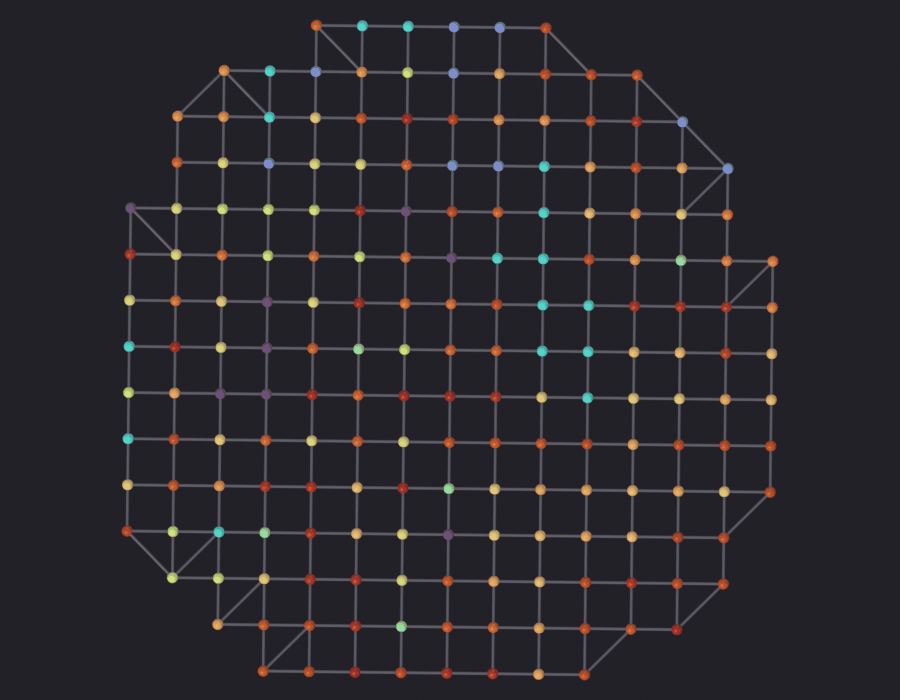

[PASS] 1_contig.png legible — 11.3% ink (healthy range 0.5–60%)
15_min_walk: 2,740 edges thinned to 364, modularity 0.034
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> node_cluster  ·  node_cluster -> turbo [log]  [0 … 17] on Point


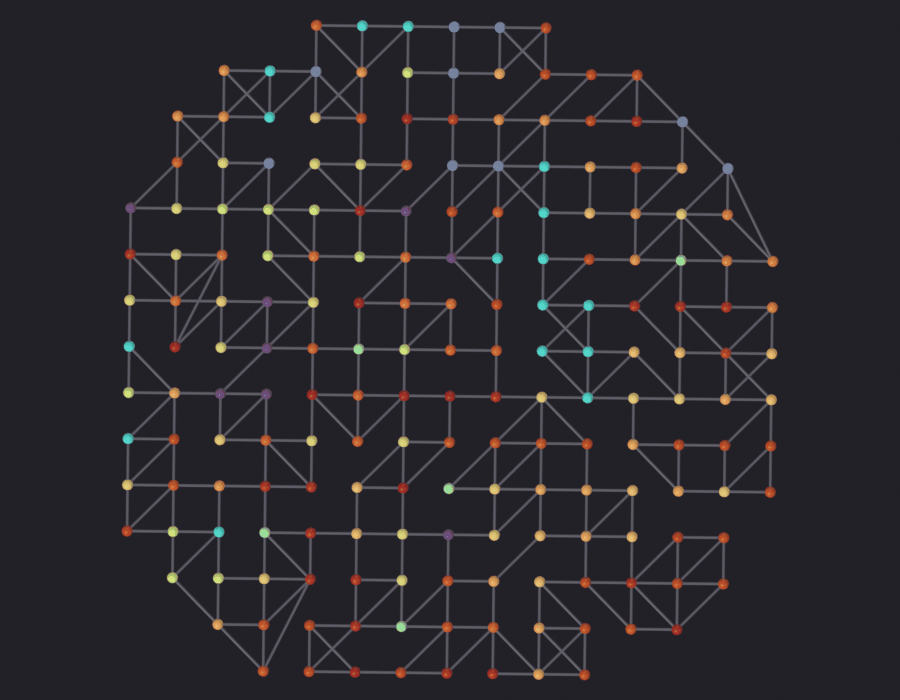

[PASS] 1_15_min_walk.png legible — 12.0% ink (healthy range 0.5–60%)
15_min_multi: 3,296 edges thinned to 470, modularity -0.008
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> node_cluster  ·  node_cluster -> turbo [log]  [0 … 17] on Point


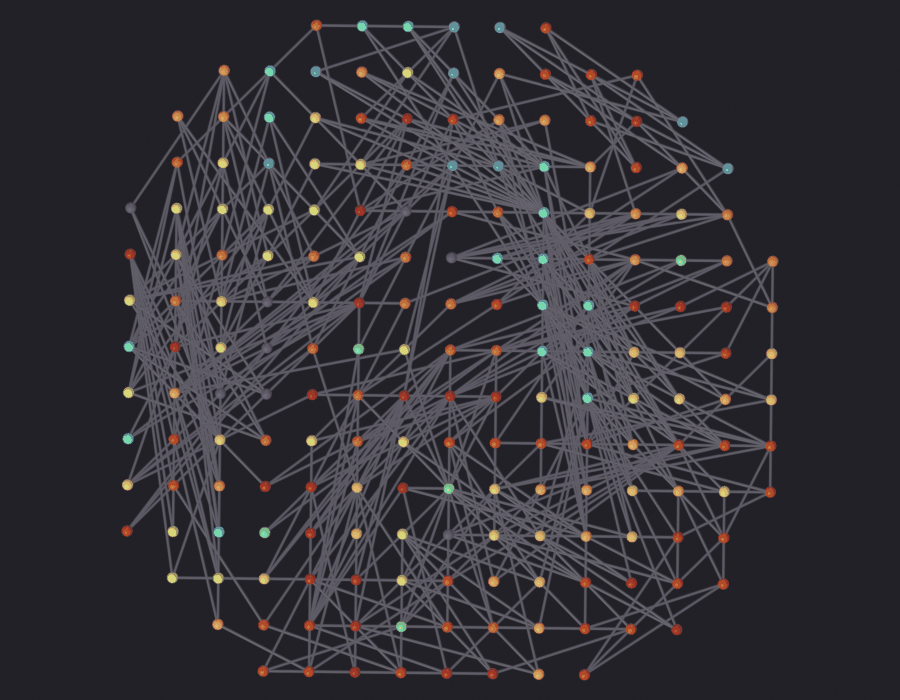

[PASS] 1_15_min_multi.png legible — 31.4% ink (healthy range 0.5–60%)


In [22]:
for name, thin_obj in backbones.items():
    full = objects[name]
    print(f"{name}: {full.get('num_edges'):,} edges thinned to "
          f"{thin_obj.get('num_edges'):,}, "
          f"modularity {modularities.get(name, float('nan')):.3f}")
    nb.figure(thin_obj, f"renders/04_case_study/1_{name}",
              resolution=(900, 700), width=800, look='ink',
              color_attribute="node_cluster", node_fraction=0.12)

# Kept in the file, since the panels above show them, but out of the renders
# below, which frame on the full relations and the ground under them.
for thin_obj in backbones.values():
    thin_obj.hide_render = True
    thin_obj.hide_viewport = True

### `contig` over the buildings that defined it

`contig` is the sparse one, queen adjacency between 250 m cells, so it needs no
backbone and goes through EEVEE with the buildings under it. Those buildings
are not decoration: section 1 kept a grid cell only if it intersected a
footprint, so this layer decided which nodes the relation has.

`terrain_source="flat"` reaches no network. Central São Paulo has real relief,
but the elevation fetch is opt-in per notebook; notebook 17 fetches a DEM. The
context radius is 1.5x the study radius, for the framing reason notebook 13
gives; the footprints came at `RADIUS_M` and a wider ground cannot invent any.

No aerial imagery either, although `add_context()` will drape it and notebooks
04 and 05 do: a photograph would compete with a categorical color scale, which
has no ordering to fall back on against a noisy background. The color is
`node_cluster`, on the POINT domain.

In [23]:
ctx = sg.context.add_context(objects.get("contig"), CENTER, RADIUS_M * 1.5,
                             anchor, buildings_gdf=buildings_osm,
                             terrain_source="flat")
print("real elevation:", ctx["real_elevation"])
sg.context.report(ctx["objects"])

Creating terrain mesh: 2x2 vertices
Terrain mesh created: 4 vertices, 1 faces
  flat ground, 5400 x 5400 m (no elevation data)
  26548 footprints -> 289228 faces, 525356 vertices
  heights: 26153 from OSM tags (98.5%), the rest at 7.2 m (median of tagged)
  context moved -0.00100 Blender units (-1.0 m) so the ground clears z=0 by 1 m
[PASS] Context_Ground aligned with Relation_contig — center off by 0.1041 BU (2.07% of the graph diagonal), covers 100.0% of it, 1.52x its width
[PASS] Context_Buildings aligned with Relation_contig — center off by 0.1057 BU (2.10% of the graph diagonal), covers 100.0% of it, 1.06x its width
real elevation: False
  Context_Ground         ground     5.400 x 5.400 x 0.000 BU   source=flat real_elevation=False imagery=none
  Context_Buildings      buildings  3.779 x 3.774 x 0.170 BU   26548 footprints, 99% tagged, default 7.2 m (median of tagged)


`isolate=False` renders everything in the scene, and the scene
holds the zone polygons and the other two relations stacked 350 and 700 m above
this one. They step out for the render.

node_cluster domain: POINT
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> node_cluster  ·  node_cluster -> turbo [log]  [0 … 17] on Point


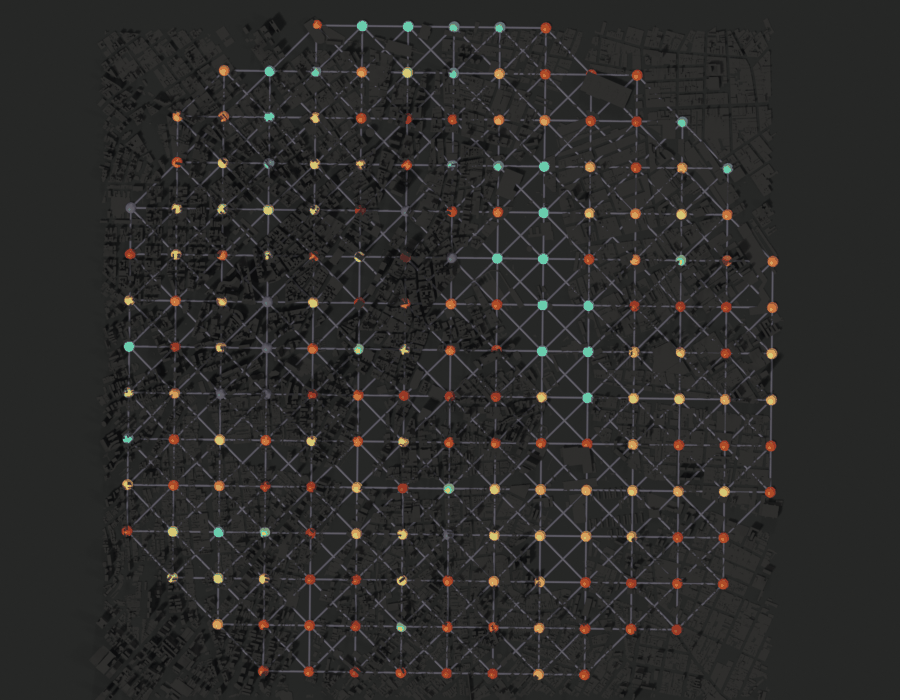

[PASS] 2_contig_over_buildings.png legible — 20.1% ink (healthy range 0.5–100%)


In [24]:
hidden = list(objs_zones) + [o for n, o in objects.items() if n != "contig"]
for obj in hidden:
    obj.hide_render = True

if "contig" in objects:
    print("node_cluster domain:",
          sg.render.attribute_domain(objects["contig"], "node_cluster"))

    # 0.12 for the reason given above. Ink ceiling lifted for the usual
    # overhead reason (notebook 13); the floor still bites.
    path = nb.render(
        objects["contig"], "renders/04_case_study/2_contig_over_buildings",
        resolution=(900, 700), isolate=False, look='ink',
        color_attribute="node_cluster", node_fraction=0.12, verbose=False)
    nb.show(path, width=800)
    nb.check_render(path, maximum=1.0)

for obj in hidden:
    obj.hide_render = False

In [25]:
if "contig" in objects:
    sg.graphs.color_by(objects["contig"], "node_cluster", colormap="turbo")
sg.graphs.frame()
print(f"Zones colored by cluster (k = {best_k}). The three stacked layers "
      "are contig (bottom), 15_min_walk and 15_min_multi (top).")

Info: Attribute -> node_cluster  ·  node_cluster -> turbo [log]  [0 … 17] on Point
Zones colored by cluster (k = 18). The three stacked layers are contig (bottom), 15_min_walk and 15_min_multi (top).


## 10 · Isochrones compared

From the same point, how far you get on foot and how far you get by bus.

In [26]:
G_walk = c2g.gdf_to_nx(nodes=connectors, edges=segments)

iso_walk = c2g.create_isochrone(
    graph=G_walk,
    center_point=connectors.geometry.iloc[
        int(np.argmin([g.distance(center_m) for g in connectors.geometry]))],
    threshold=[300, 600, 900],
    edge_attr="travel_time")

print("pedestrian isochrones (m2):")
for threshold, area in zip([300, 600, 900], iso_walk.geometry.area):
    print(f"  {threshold // 60:>2} min  {area:>12,.0f}")

sg.graphs.from_features(iso_walk, name="Isochrones_Walk", ref=anchor,
                        coll="C2G_CaseStudy")

pedestrian isochrones (m2):
   5 min       241,450
  10 min     1,103,941
  15 min     2,803,227
Using reference projection: center=(-23.550500, -46.633300), scale=0.001
Created 1 object(s) from GeoDataFrame with 3 features


[bpy.data.objects['Isochrones_Walk']]

The multimodal one uses the three-layer graph. `cut_edge_types`
exists for this: bus segments connect distant points, and a concave hull over
them would claim everything between two stops, when you can only walk from each
stop.

In [27]:
G_multi = c2g.gdf_to_nx(nodes=nodes_multi, edges=edges_multi)

try:
    iso_multi = c2g.create_isochrone(
        graph=G_multi,
        center_point=zones_pt.geometry.iloc[
            int(np.argmin([g.distance(center_m) for g in zones_pt.geometry]))],
        threshold=[300, 600, 900],
        edge_attr="travel_time",
        cut_edge_types=[("bus_station", "is_next_to", "bus_station")])
    print("multimodal isochrones (m2):")
    for threshold, area in zip([300, 600, 900], iso_multi.geometry.area):
        print(f"  {threshold // 60:>2} min  {area:>12,.0f}")
    sg.graphs.from_features(iso_multi, name="Isochrones_Multimodal", ref=anchor,
                            coll="C2G_CaseStudy")

    ratio = iso_multi.geometry.area.iloc[-1] / iso_walk.geometry.area.iloc[-1]
    print(f"\nthe bus multiplies the area reachable in 15 min by {ratio:.1f}")
except Exception as exc:
    print("multimodal isochrone not available:", type(exc).__name__, exc)

multimodal isochrones (m2):
   5 min       231,955
  10 min     2,261,818
  15 min     7,273,221
Using reference projection: center=(-23.550500, -46.633300), scale=0.001
Created 1 object(s) from GeoDataFrame with 3 features

the bus multiplies the area reachable in 15 min by 2.6


## 11 · Saving

In [28]:
sg.graphs.save_gdf(zones.assign(cluster=best_labels).join(attributes),
                   OUTPUT_DIR / "zones_clusters.gpkg")
for key, gdf in edges_final.items():
    sg.graphs.save_gdf(gdf, OUTPUT_DIR / f"relation_{key[1]}.gpkg")
attributes.to_csv(OUTPUT_DIR / "urban_function_attributes.csv")
pd.DataFrame([{"k": k, "silhouette": s} for k, s, _ in results]).to_csv(
    OUTPUT_DIR / "silhouette_by_k.csv", index=False)

print("written to", nb.rel(OUTPUT_DIR))
for f in sorted(OUTPUT_DIR.iterdir()):
    print("  ", f.name, f"{f.stat().st_size / 1e3:.0f} kB")

written to notebooks/out/18_case_study
   relation_15_min_multi.gpkg 762 kB
   relation_15_min_walk.gpkg 664 kB
   relation_contig.gpkg 221 kB
   silhouette_by_k.csv 0 kB
   urban_function_attributes.csv 22 kB
   zones_clusters.gpkg 147 kB


## 12 · Swapping in real units, a real feed and richer POIs

The grid, the São Paulo feed and the OSM tags are each replaceable without
touching the rest of the workflow. England and Wales, where all three are open:

Census units and population-weighted centroids (ONS, United Kingdom):

- <https://geoportal.statistics.gov.uk/datasets/6beafcfd9b9c4c9993a06b6b199d7e6d_0>
- <https://geoportal.statistics.gov.uk/datasets/ons::output-areas-december-2021-ew-population-weighted-centroids-v3>

```python
zones = gpd.read_file("OA_2021_EW_BGC.gpkg")
zones = zones[zones["LAD22NM"] == "Manchester"].set_index("OA21CD").to_crs("EPSG:27700")
```

Bus GTFS for England (Department for Transport):
<https://data.bus-data.dft.gov.uk/timetable/download/bus-open-data>. Swap
`GTFS_FEED` for that zip.

POIs and land use from Overture, instead of OSM:

```python
data = c2g.load_overture_data(bbox, types=["place", "land_use", "segment", "connector"])
```

Slower, since it reads remote GeoParquet, but its place categories are
normalized, so the 16 POI classes come out of one column instead of the OSM tag
rules in section 2.

For embeddings, `examples/city2graph-case-study-main/` has graph-autoencoder
code that runs in a normal Python environment with PyTorch, not inside Blender.
`gdf_to_pyg()` / `pyg_to_gdf()` is the bridge; the embeddings come back as node
columns to color by.

## Rendering

Every figure here is EEVEE, straight down through an orthographic camera,
colored by a number the notebook computed. Notebook 13 explains that path:
Geometry Nodes glyphs, the three-sun rig, the legibility check. Each render is
drawn right after the step that made its object, into `notebooks/out/renders/`.

> The Vulkan warning no longer applies to anything here, but it is worth
> carrying if you switch a figure back to the SciGraphs engine: on Blender's
> Vulkan backend, the default on Linux, `gpu.state.point_size_set` does nothing
> for the add-on shaders, so `POINT` and `DISK` nodes come out 1 pixel wide.
> Start Blender with `--gpu-backend opengl` for any SciGraphs-engine render you
> intend to look at. EEVEE is unaffected, and so are `SPHERE` impostors, which
> are real geometry.

## Summary

Built: the 23-dimensional urban function matrix, the three relations with the
walk/multi exclusion, PCA + K-Means scored by silhouette and by modularity per
relation, and pedestrian and multimodal isochrones. Left out: training a graph
autoencoder (it needs PyTorch) and real census boundaries (section 12).

Next: **07 · Reproducible pipelines**.